# LoRaWAN EU863-870 MHz Band Plan (TTN Scheme)

This notebook visualizes the **EU863-870 LoRaWAN band plan** as deployed by **The Things Network (TTN)**, including **LR-FHSS** and **Wake-on-Radio (WoR / Class B)** channels.

### Regulatory context
The EU863-870 plan does **not** prescribe fixed channel frequencies — network operators assign them freely.  
However, the LoRaWAN spec mandates **3 default channels** that every end-device must support at boot:

| Channel | Frequency | DR | BW |
|---------|-----------|----|----|
| Default 0 | 868.1 MHz | DR0–DR5 | 125 kHz |
| Default 1 | 868.3 MHz | DR0–DR5 (+DR6) | 125 kHz (250 kHz for DR6) |
| Default 2 | 868.5 MHz | DR0–DR5 | 125 kHz |

### TTN 8-channel plan + LR-FHSS + WoR

| Group | Channels | Frequencies | DR | BW / Notes |
|-------|----------|-------------|----|-----------|
| Mandatory | 0–2 | 868.1, 868.3, 868.5 MHz | DR0–DR5 | 125 kHz |
| Additional | 3–7 | 867.1, 867.3, 867.5, 867.7, 867.9 MHz | DR0–DR5 | 125 kHz |
| LoRa 250k | — | 868.3 MHz | DR6 | 250 kHz |
| FSK | — | 868.8 MHz | DR7 | FSK 50 kbps |
| **LR-FHSS 137k** | 0–7 | 867.1–868.5 MHz (same CF) | DR8, DR9 | OCW 137 kHz, GRID 3.9 kHz |
| **LR-FHSS 336k** | 0–7 | 867.1–868.5 MHz (same CF) | DR10, DR11 | OCW 336 kHz, GRID 3.9 kHz |
| **Class B beacon** | — | 869.525 MHz | DR3 (SF9/125k) | Broadcast every 128 s |
| **WoR uplink** | 0–7 | 867.1–868.5 MHz (same CF) | DR0–DR5 | 125 kHz, WoR preamble |
| RX2 default | — | 869.525 MHz | DR0 | 125 kHz |

### Data Rates
| DR | Modulation | SF | BW | Approx. bitrate |
|----|-----------|----|----|----------------|
| DR0 | LoRa | SF12 | 125 kHz | 0.25 kbps |
| DR1 | LoRa | SF11 | 125 kHz | 0.44 kbps |
| DR2 | LoRa | SF10 | 125 kHz | 0.98 kbps |
| DR3 | LoRa | SF9  | 125 kHz | 1.76 kbps |
| DR4 | LoRa | SF8  | 125 kHz | 3.13 kbps |
| DR5 | LoRa | SF7  | 125 kHz | 5.47 kbps |
| DR6 | LoRa | SF7  | 250 kHz | 11.0 kbps |
| DR7 | FSK  | —   | 50 kbps | 50.0 kbps |
| DR8 | LR-FHSS | CR1/3 | OCW 137 kHz | ~162 bps |
| DR9 | LR-FHSS | CR2/3 | OCW 137 kHz | ~325 bps |
| DR10 | LR-FHSS | CR1/3 | OCW 336 kHz | ~162 bps |
| DR11 | LR-FHSS | CR2/3 | OCW 336 kHz | ~325 bps |

> **LR-FHSS** channels share center frequencies with the 8 uplink channels but hop across the physical bandwidth using a 3.9 kHz grid.  
> **Class B / WoR** uses 869.525 MHz for the periodic gateway beacon; end-device ping slots are derived from that timing on uplink channel frequencies.

In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
import numpy as np

## Channel Definitions

In [9]:
# ── Bandwidth constants (MHz) ──────────────────────────────────────────────────
BW_125        = 0.125   # LoRa 125 kHz
BW_250        = 0.250   # LoRa 250 kHz
BW_FSK        = 0.050   # FSK represented as 50 kHz occupancy
BW_LRFHSS_137 = 0.137   # LR-FHSS OCW 137 kHz (DR8/DR9)
BW_LRFHSS_336 = 0.336   # LR-FHSS OCW 336 kHz (DR10/DR11)

# ── Data Rate table ────────────────────────────────────────────────────────────
DR_TABLE = {
    0:  "DR0   SF12/125k      0.25 kbps",
    1:  "DR1   SF11/125k      0.44 kbps",
    2:  "DR2   SF10/125k      0.98 kbps",
    3:  "DR3   SF9/125k       1.76 kbps",
    4:  "DR4   SF8/125k       3.13 kbps",
    5:  "DR5   SF7/125k       5.47 kbps",
    6:  "DR6   SF7/250k      11.0  kbps",
    7:  "DR7   FSK/50k       50.0  kbps",
    8:  "DR8   LR-FHSS CR1/3 OCW137   ~162 bps",
    9:  "DR9   LR-FHSS CR2/3 OCW137   ~325 bps",
    10: "DR10  LR-FHSS CR1/3 OCW336   ~162 bps",
    11: "DR11  LR-FHSS CR2/3 OCW336   ~325 bps",
}

# ── 8 shared uplink center frequencies (mandatory 0-2 + additional 3-7) ───────
UPLINK_CF = [868.1, 868.3, 868.5, 867.1, 867.3, 867.5, 867.7, 867.9]

# ── Mandatory default channels (0–2) ──────────────────────────────────────────
mandatory_channels = [
    {"ch": 0, "fc": 868.1, "bw": BW_125, "dr": "DR0–DR5", "label": "M0"},
    {"ch": 1, "fc": 868.3, "bw": BW_125, "dr": "DR0–DR5", "label": "M1"},
    {"ch": 2, "fc": 868.5, "bw": BW_125, "dr": "DR0–DR5", "label": "M2"},
]

# ── Additional TTN channels (3–7) ─────────────────────────────────────────────
additional_channels = [
    {"ch": 3, "fc": 867.1, "bw": BW_125, "dr": "DR0–DR5", "label": "A3"},
    {"ch": 4, "fc": 867.3, "bw": BW_125, "dr": "DR0–DR5", "label": "A4"},
    {"ch": 5, "fc": 867.5, "bw": BW_125, "dr": "DR0–DR5", "label": "A5"},
    {"ch": 6, "fc": 867.7, "bw": BW_125, "dr": "DR0–DR5", "label": "A6"},
    {"ch": 7, "fc": 867.9, "bw": BW_125, "dr": "DR0–DR5", "label": "A7"},
]

# ── DR6 – LoRa 250 kHz (same centre as M1 at 868.3 MHz) ──────────────────────
dr6_channel = {"ch": 1, "fc": 868.3, "bw": BW_250, "dr": "DR6 SF7/250k", "label": "DR6"}

# ── FSK channel ───────────────────────────────────────────────────────────────
fsk_channel = {"ch": None, "fc": 868.8, "bw": BW_FSK, "dr": "DR7 FSK 50kbps", "label": "FSK"}

# ── LR-FHSS channels – 8 channels on same CFs as uplink ──────────────────────
# DR8/DR9: OCW 137 kHz | DR10/DR11: OCW 336 kHz
# Channels hop across the physical OCW on a 3.9 kHz grid
lrfhss_137_channels = [{"ch": i, "fc": fc, "bw": BW_LRFHSS_137, "dr": "DR8/DR9"}
                        for i, fc in enumerate(UPLINK_CF)]
lrfhss_336_channels = [{"ch": i, "fc": fc, "bw": BW_LRFHSS_336, "dr": "DR10/DR11"}
                        for i, fc in enumerate(UPLINK_CF)]

# ── Class B beacon + WoR (Wake-on-Radio) ─────────────────────────────────────
# Beacon: 869.525 MHz, DR3 (SF9/BW125), broadcast by gateway every 128 s
# WoR uplink ping slots: derived from DEVEUI hash across the 8 uplink CFs
# WoR preamble uses 5x longer preamble on DR0–DR5 (same frequencies/BW)
beacon_channel = {"fc": 869.525, "bw": BW_125, "dr": "DR3 SF9/125k",
                  "label": "Beacon", "period": "128 s"}
wor_channels = [{"ch": i, "fc": fc, "bw": BW_125, "dr": "DR0–DR5 + WoR preamble"}
                for i, fc in enumerate(UPLINK_CF)]

# ── RX2 / default downlink window ─────────────────────────────────────────────
rx2_channel = {"ch": None, "fc": 869.525, "bw": BW_125, "dr": "DR0 SF12/125k", "label": "RX2"}

# ── Print summary ─────────────────────────────────────────────────────────────
print("Mandatory default channels:")
for c in mandatory_channels:
    print(f"  Ch {c['ch']}  {c['fc']:.3f} MHz  {c['dr']}  BW={int(c['bw']*1000)} kHz")

print("\nAdditional TTN channels:")
for c in additional_channels:
    print(f"  Ch {c['ch']}  {c['fc']:.3f} MHz  {c['dr']}  BW={int(c['bw']*1000)} kHz")

print(f"\nDR6 : {dr6_channel['fc']:.3f} MHz  {dr6_channel['dr']}  BW={int(dr6_channel['bw']*1000)} kHz")
print(f"FSK : {fsk_channel['fc']:.3f} MHz  {fsk_channel['dr']}")

print(f"\nLR-FHSS OCW 137 kHz (DR8/DR9):  8 channels")
for c in lrfhss_137_channels:
    print(f"  Ch {c['ch']}  {c['fc']:.3f} MHz")

print(f"\nLR-FHSS OCW 336 kHz (DR10/DR11): 8 channels")
for c in lrfhss_336_channels:
    print(f"  Ch {c['ch']}  {c['fc']:.3f} MHz")

print(f"\nClass B Beacon: {beacon_channel['fc']:.3f} MHz  {beacon_channel['dr']}  period={beacon_channel['period']}")
print(f"WoR uplink: {len(wor_channels)} channels on same CFs as uplink")
print(f"RX2 : {rx2_channel['fc']:.3f} MHz  {rx2_channel['dr']}")

Mandatory default channels:
  Ch 0  868.100 MHz  DR0–DR5  BW=125 kHz
  Ch 1  868.300 MHz  DR0–DR5  BW=125 kHz
  Ch 2  868.500 MHz  DR0–DR5  BW=125 kHz

Additional TTN channels:
  Ch 3  867.100 MHz  DR0–DR5  BW=125 kHz
  Ch 4  867.300 MHz  DR0–DR5  BW=125 kHz
  Ch 5  867.500 MHz  DR0–DR5  BW=125 kHz
  Ch 6  867.700 MHz  DR0–DR5  BW=125 kHz
  Ch 7  867.900 MHz  DR0–DR5  BW=125 kHz

DR6 : 868.300 MHz  DR6 SF7/250k  BW=250 kHz
FSK : 868.800 MHz  DR7 FSK 50kbps

LR-FHSS OCW 137 kHz (DR8/DR9):  8 channels
  Ch 0  868.100 MHz
  Ch 1  868.300 MHz
  Ch 2  868.500 MHz
  Ch 3  867.100 MHz
  Ch 4  867.300 MHz
  Ch 5  867.500 MHz
  Ch 6  867.700 MHz
  Ch 7  867.900 MHz

LR-FHSS OCW 336 kHz (DR10/DR11): 8 channels
  Ch 0  868.100 MHz
  Ch 1  868.300 MHz
  Ch 2  868.500 MHz
  Ch 3  867.100 MHz
  Ch 4  867.300 MHz
  Ch 5  867.500 MHz
  Ch 6  867.700 MHz
  Ch 7  867.900 MHz

Class B Beacon: 869.525 MHz  DR3 SF9/125k  period=128 s
WoR uplink: 8 channels on same CFs as uplink
RX2 : 869.525 MHz  DR0 SF12/

## Band Plan Visualization

The plot shows all channel groups as horizontal bars with width proportional to bandwidth.  
Background shading indicates EU regulatory **duty cycle** sub-bands.

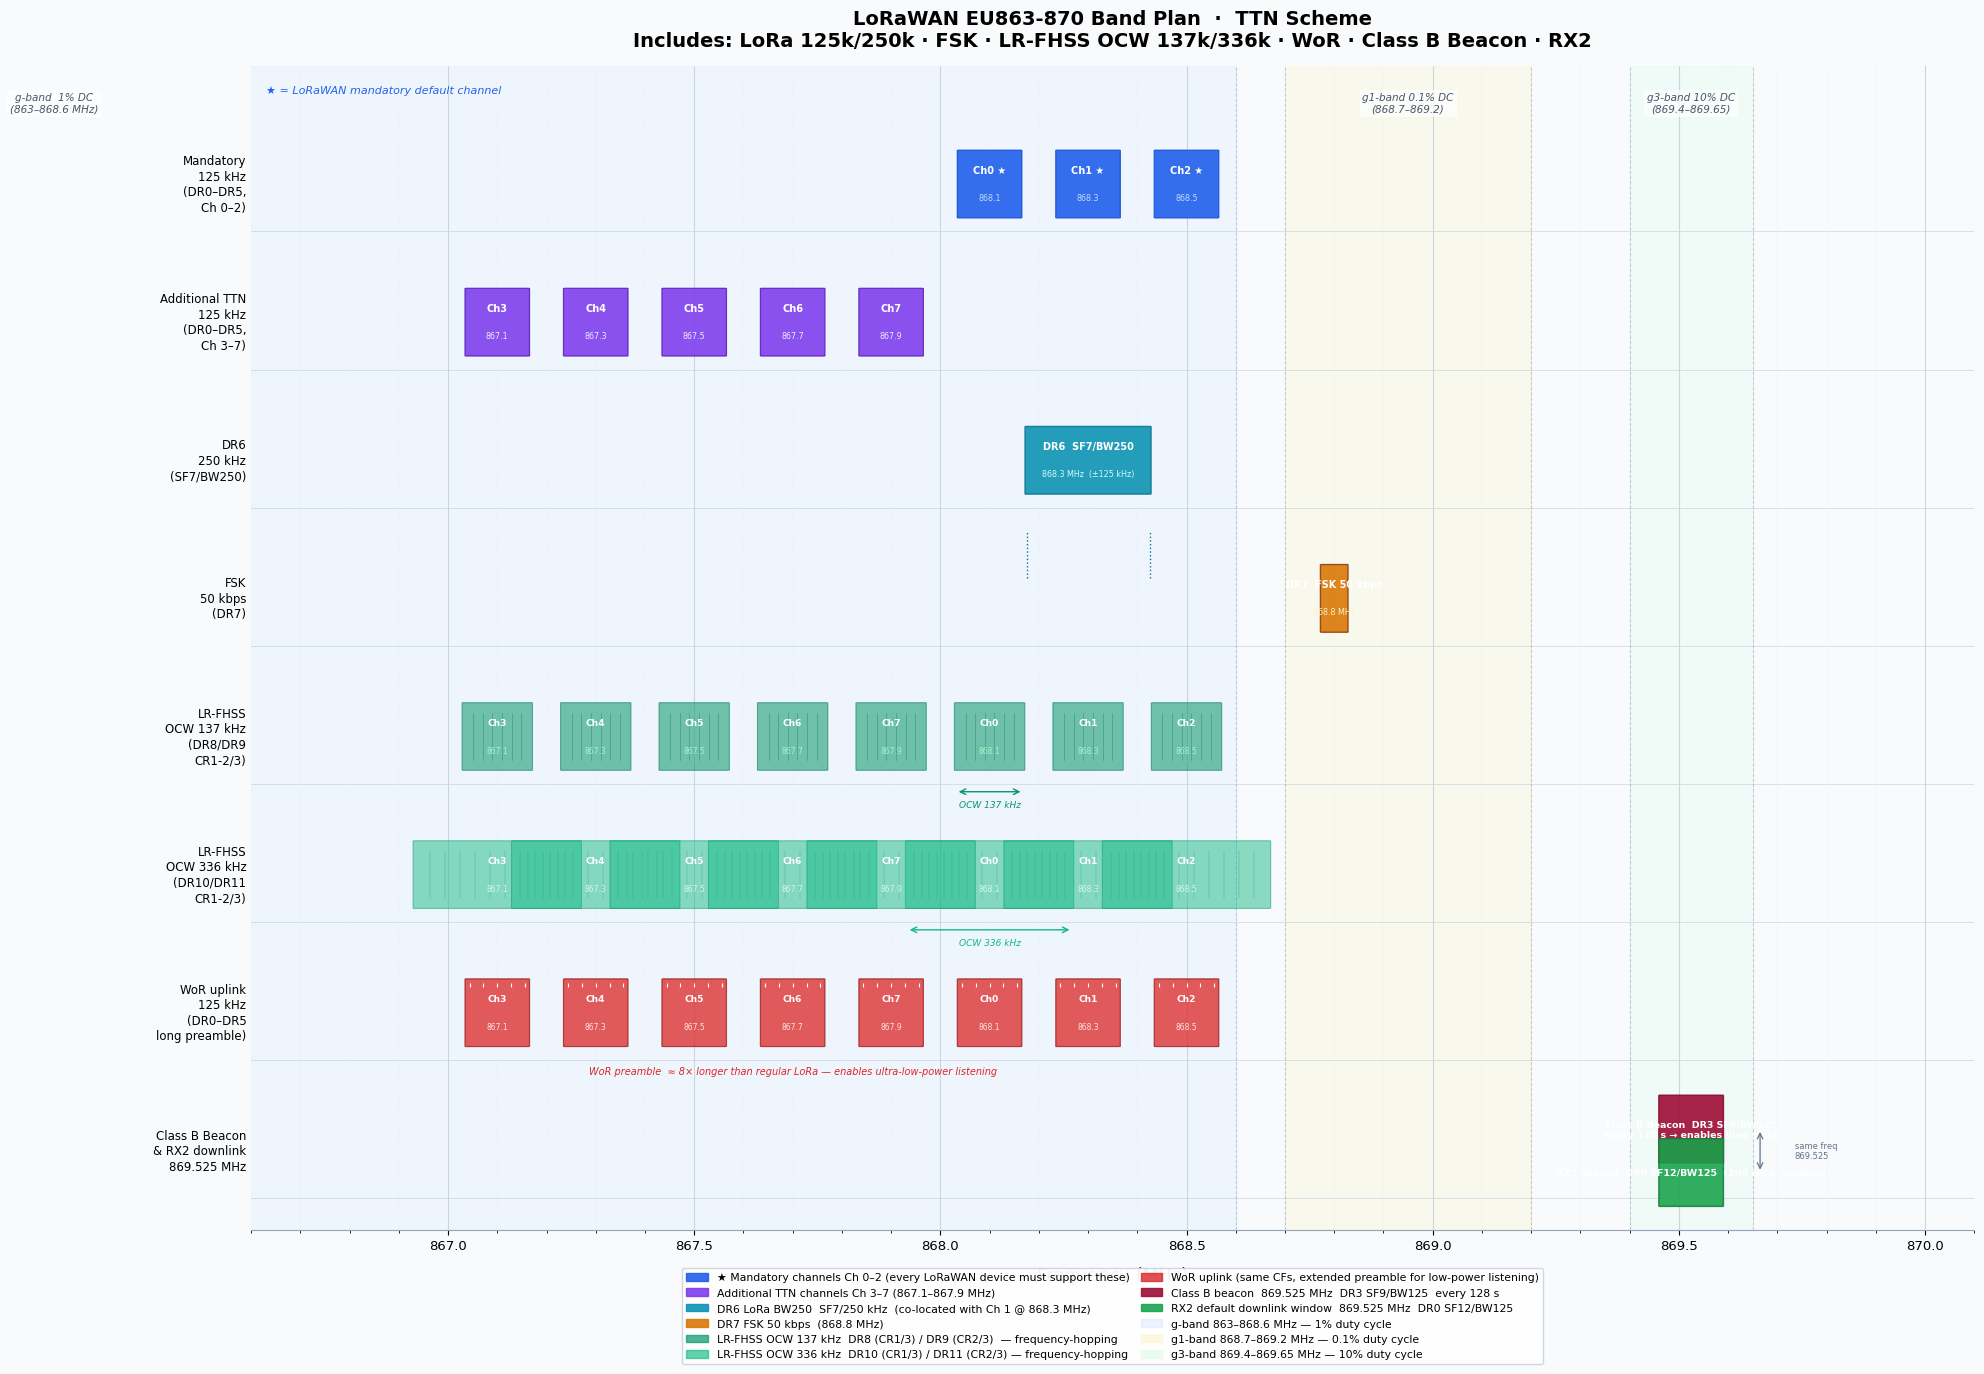

Saved → eu868_band_plan.png


In [10]:
%matplotlib inline

# ── Color palette ──────────────────────────────────────────────────────────────
C_MAND        = "#2563EB"   # blue         – mandatory channels
C_ADD         = "#7C3AED"   # violet       – additional TTN
C_DR6         = "#0891B2"   # cyan         – DR6 250 kHz
C_FSK         = "#D97706"   # amber        – FSK
C_LRFHSS_137  = "#059669"   # emerald      – LR-FHSS OCW 137
C_LRFHSS_336  = "#10B981"   # green-teal   – LR-FHSS OCW 336
C_WOR         = "#DC2626"   # red          – WoR uplink
C_BEACON      = "#9F1239"   # dark rose    – Class B beacon
C_RX2         = "#16A34A"   # green        – RX2
C_SUBG        = "#DBEAFE"   # sub-band g
C_SUBG1       = "#FEF3C7"   # sub-band g1
C_SUBG3       = "#DCFCE7"   # sub-band g3

ROW_H = 0.68

# ── Row y-positions ────────────────────────────────────────────────────────────
rows = {
    "Mandatory\n125 kHz\n(DR0–DR5,\nCh 0–2)":          8.6,
    "Additional TTN\n125 kHz\n(DR0–DR5,\nCh 3–7)":     7.2,
    "DR6\n250 kHz\n(SF7/BW250)":                        5.8,
    "FSK\n50 kbps\n(DR7)":                              4.4,
    "LR-FHSS\nOCW 137 kHz\n(DR8/DR9\nCR1-2/3)":        3.0,
    "LR-FHSS\nOCW 336 kHz\n(DR10/DR11\nCR1-2/3)":      1.6,
    "WoR uplink\n125 kHz\n(DR0–DR5\nlong preamble)":    0.2,
    "Class B Beacon\n& RX2 downlink\n869.525 MHz":      -1.2,
}


def draw_bar(ax, fc, bw, y, color, alpha=0.88, edgecolor="white", lw=0.5, zorder=3):
    x0 = fc - bw / 2
    rect = mpatches.FancyBboxPatch(
        (x0, y - ROW_H / 2), bw, ROW_H,
        boxstyle="round,pad=0.003",
        linewidth=lw, edgecolor=edgecolor,
        facecolor=color, alpha=alpha, zorder=zorder,
    )
    ax.add_patch(rect)


def label_bar(ax, fc, y, top_txt, bot_txt, top_fs=7.0, bot_fs=5.8,
              top_col="white", bot_col="white"):
    ax.text(fc, y + 0.14, top_txt, ha="center", va="center",
            fontsize=top_fs, fontweight="bold", color=top_col, clip_on=True, zorder=5)
    ax.text(fc, y - 0.14, bot_txt, ha="center", va="center",
            fontsize=bot_fs, color=bot_col, clip_on=True, zorder=5)


# ── Figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(20, 14))
fig.patch.set_facecolor("#F8FAFC")
ax.set_facecolor("#F8FAFC")

# ── EU duty-cycle sub-band shading ────────────────────────────────────────────
dc_bands = [
    (863.0, 868.6, C_SUBG,  "g-band  1% DC\n(863–868.6 MHz)",  866.2),
    (868.7, 869.2, C_SUBG1, "g1-band 0.1% DC\n(868.7–869.2)",  868.95),
    (869.4, 869.65, C_SUBG3, "g3-band 10% DC\n(869.4–869.65)", 869.525),
]
for (x0, x1, col, lbl, lbl_x) in dc_bands:
    ax.axvspan(x0, x1, alpha=0.28, color=col, zorder=0)
    ax.text(lbl_x, 9.42, lbl, ha="center", va="center",
            fontsize=7.5, color="#475569", fontstyle="italic",
            bbox=dict(fc="white", alpha=0.65, ec="none", pad=2))
for xb in [863.0, 868.6, 868.7, 869.2, 869.4, 869.65]:
    ax.axvline(xb, color="#94A3B8", lw=0.7, linestyle="--", alpha=0.55, zorder=1)

# ── Row 1: Mandatory channels ─────────────────────────────────────────────────
y1 = rows["Mandatory\n125 kHz\n(DR0–DR5,\nCh 0–2)"]
for c in mandatory_channels:
    draw_bar(ax, c["fc"], c["bw"], y1, C_MAND, alpha=0.92, edgecolor="#1D4ED8", lw=0.9)
    label_bar(ax, c["fc"], y1, f"Ch{c['ch']} ★", f"{c['fc']:.1f}", top_col="white", bot_col="#BFDBFE")

# ── Row 2: Additional TTN channels ───────────────────────────────────────────
y2 = rows["Additional TTN\n125 kHz\n(DR0–DR5,\nCh 3–7)"]
for c in additional_channels:
    draw_bar(ax, c["fc"], c["bw"], y2, C_ADD, alpha=0.88, edgecolor="#5B21B6", lw=0.9)
    label_bar(ax, c["fc"], y2, f"Ch{c['ch']}", f"{c['fc']:.1f}", top_col="white", bot_col="#EDE9FE")

# ── Row 3: DR6 / 250 kHz ─────────────────────────────────────────────────────
y3 = rows["DR6\n250 kHz\n(SF7/BW250)"]
draw_bar(ax, dr6_channel["fc"], dr6_channel["bw"], y3, C_DR6, alpha=0.88, edgecolor="#0E7490", lw=1.0)
label_bar(ax, dr6_channel["fc"], y3,
          "DR6  SF7/BW250",
          f"{dr6_channel['fc']:.1f} MHz  (±125 kHz)",
          top_col="white", bot_col="#CFFAFE")
for side in [-1, 1]:
    ax.axvline(dr6_channel["fc"] + side * dr6_channel["bw"] / 2,
               ymin=0.560, ymax=0.600, color="#0E7490", lw=1.0, linestyle=":", zorder=4)

# ── Row 4: FSK channel ────────────────────────────────────────────────────────
y4 = rows["FSK\n50 kbps\n(DR7)"]
draw_bar(ax, fsk_channel["fc"], fsk_channel["bw"], y4, C_FSK, alpha=0.90, edgecolor="#92400E", lw=1.0)
label_bar(ax, fsk_channel["fc"], y4,
          "DR7  FSK 50 kbps",
          f"{fsk_channel['fc']:.1f} MHz",
          top_col="white", bot_col="#FEF3C7")

# ── Row 5: LR-FHSS OCW 137 kHz (DR8/DR9) ────────────────────────────────────
y5 = rows["LR-FHSS\nOCW 137 kHz\n(DR8/DR9\nCR1-2/3)"]
for c in lrfhss_137_channels:
    draw_bar(ax, c["fc"], c["bw"], y5, C_LRFHSS_137, alpha=0.55, edgecolor="#047857", lw=0.8)
    # Hopping grid indicator (zigzag lines inside the OCW)
    n_hops = 6
    hop_bw = c["bw"] / (n_hops + 1)
    for h in range(n_hops):
        hx = (c["fc"] - c["bw"] / 2) + hop_bw * (h + 1)
        ax.plot([hx, hx], [y5 - ROW_H*0.35, y5 + ROW_H*0.35],
                color="#047857", lw=0.4, alpha=0.6, zorder=4)
    label_bar(ax, c["fc"], y5, f"Ch{c['ch']}", f"{c['fc']:.1f}",
              top_col="white", bot_col="#A7F3D0", top_fs=6.5, bot_fs=5.5)

# OCW boundary arrows for first channel
c0 = lrfhss_137_channels[0]
ax.annotate("", xy=(c0["fc"] - c0["bw"]/2, y5 - ROW_H/2 - 0.22),
            xytext=(c0["fc"] + c0["bw"]/2, y5 - ROW_H/2 - 0.22),
            arrowprops=dict(arrowstyle="<->", color=C_LRFHSS_137, lw=1.0), zorder=5)
ax.text(c0["fc"], y5 - ROW_H/2 - 0.38, "OCW 137 kHz",
        ha="center", fontsize=6.5, color=C_LRFHSS_137, fontstyle="italic")

# ── Row 6: LR-FHSS OCW 336 kHz (DR10/DR11) ──────────────────────────────────
y6 = rows["LR-FHSS\nOCW 336 kHz\n(DR10/DR11\nCR1-2/3)"]
for c in lrfhss_336_channels:
    draw_bar(ax, c["fc"], c["bw"], y6, C_LRFHSS_336, alpha=0.48, edgecolor="#059669", lw=0.8)
    n_hops = 10
    hop_bw = c["bw"] / (n_hops + 1)
    for h in range(n_hops):
        hx = (c["fc"] - c["bw"] / 2) + hop_bw * (h + 1)
        ax.plot([hx, hx], [y6 - ROW_H*0.35, y6 + ROW_H*0.35],
                color="#059669", lw=0.35, alpha=0.5, zorder=4)
    label_bar(ax, c["fc"], y6, f"Ch{c['ch']}", f"{c['fc']:.1f}",
              top_col="white", bot_col="#D1FAE5", top_fs=6.5, bot_fs=5.5)

c0 = lrfhss_336_channels[0]
ax.annotate("", xy=(c0["fc"] - c0["bw"]/2, y6 - ROW_H/2 - 0.22),
            xytext=(c0["fc"] + c0["bw"]/2, y6 - ROW_H/2 - 0.22),
            arrowprops=dict(arrowstyle="<->", color=C_LRFHSS_336, lw=1.0), zorder=5)
ax.text(c0["fc"], y6 - ROW_H/2 - 0.38, "OCW 336 kHz",
        ha="center", fontsize=6.5, color=C_LRFHSS_336, fontstyle="italic")

# ── Row 7: WoR uplink ────────────────────────────────────────────────────────
y7 = rows["WoR uplink\n125 kHz\n(DR0–DR5\nlong preamble)"]
for c in wor_channels:
    draw_bar(ax, c["fc"], c["bw"], y7, C_WOR, alpha=0.75, edgecolor="#991B1B", lw=0.9)
    # Long preamble indicator: dashes before/after bar
    for dx in np.linspace(-c["bw"]*0.45, c["bw"]*0.45, 5):
        ax.plot(c["fc"] + dx, y7 + ROW_H*0.42, marker="|",
                color="white", ms=3.5, mew=0.8, zorder=5)
    label_bar(ax, c["fc"], y7, f"Ch{c['ch']}", f"{c['fc']:.1f}",
              top_col="white", bot_col="#FEE2E2", top_fs=6.5, bot_fs=5.5)
ax.text(867.7, y7 - ROW_H/2 - 0.28,
        "WoR preamble  ≈ 8× longer than regular LoRa — enables ultra-low-power listening",
        ha="center", fontsize=7, color=C_WOR, fontstyle="italic")

# ── Row 8: Class B Beacon + RX2 ──────────────────────────────────────────────
y8 = rows["Class B Beacon\n& RX2 downlink\n869.525 MHz"]

# Class B beacon (slightly offset upward within row)
draw_bar(ax, beacon_channel["fc"], beacon_channel["bw"], y8 + 0.22,
         C_BEACON, alpha=0.92, edgecolor="#881337", lw=1.1, zorder=4)
ax.text(beacon_channel["fc"], y8 + 0.22,
        "Class B Beacon  DR3 SF9/BW125\nevery 128 s → enables ping slots",
        ha="center", va="center", fontsize=6.8, fontweight="bold",
        color="white", clip_on=True, zorder=5)

# RX2 default (slightly offset downward)
draw_bar(ax, rx2_channel["fc"], rx2_channel["bw"], y8 - 0.22,
         C_RX2, alpha=0.88, edgecolor="#15803D", lw=1.1, zorder=4)
ax.text(rx2_channel["fc"], y8 - 0.22,
        "RX2 default  DR0 SF12/BW125  (2nd recv. window)",
        ha="center", va="center", fontsize=6.8, fontweight="bold",
        color="white", clip_on=True, zorder=5)

# Bracket indicating both share 869.525 MHz
ax.annotate("", xy=(beacon_channel["fc"] + 0.14, y8 + 0.22),
            xytext=(beacon_channel["fc"] + 0.14, y8 - 0.22),
            arrowprops=dict(arrowstyle="<->", color="#64748B", lw=0.9), zorder=5)
ax.text(beacon_channel["fc"] + 0.21, y8, "same freq\n869.525",
        fontsize=6, color="#64748B", va="center", ha="left")

# ── Axes ──────────────────────────────────────────────────────────────────────
ax.set_xlim(866.6, 870.1)
ax.set_ylim(-2.0, 9.8)
ax.set_xlabel("Frequency (MHz)", fontsize=13, labelpad=10)
ax.set_title("LoRaWAN EU863-870 Band Plan  ·  TTN Scheme\n"
             "Includes: LoRa 125k/250k · FSK · LR-FHSS OCW 137k/336k · WoR · Class B Beacon · RX2",
             fontsize=14, fontweight="bold", pad=14)

ax.xaxis.set_major_locator(ticker.MultipleLocator(0.5))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.1))
ax.tick_params(axis="x", which="major", labelsize=9.5)

ax.set_yticks(list(rows.values()))
ax.set_yticklabels(list(rows.keys()), fontsize=8.5, va="center", linespacing=1.25)
ax.yaxis.set_tick_params(length=0)

ax.spines[["top", "right", "left"]].set_visible(False)
ax.spines["bottom"].set_color("#94A3B8")
ax.xaxis.grid(True, which="major", color="#CBD5E1", linewidth=0.8, zorder=0)
ax.xaxis.grid(True, which="minor", color="#E2E8F0", linewidth=0.3, linestyle=":", zorder=0)
ax.set_axisbelow(True)
for y in rows.values():
    ax.axhline(y - ROW_H / 2 - 0.14, color="#CBD5E1", linewidth=0.5, zorder=0)

# ── Legend ────────────────────────────────────────────────────────────────────
legend_handles = [
    mpatches.Patch(color=C_MAND,       alpha=0.92, label="★ Mandatory channels Ch 0–2 (every LoRaWAN device must support these)"),
    mpatches.Patch(color=C_ADD,        alpha=0.88, label="Additional TTN channels Ch 3–7 (867.1–867.9 MHz)"),
    mpatches.Patch(color=C_DR6,        alpha=0.88, label="DR6 LoRa BW250  SF7/250 kHz  (co-located with Ch 1 @ 868.3 MHz)"),
    mpatches.Patch(color=C_FSK,        alpha=0.90, label="DR7 FSK 50 kbps  (868.8 MHz)"),
    mpatches.Patch(color=C_LRFHSS_137, alpha=0.70, label="LR-FHSS OCW 137 kHz  DR8 (CR1/3) / DR9 (CR2/3)  — frequency-hopping"),
    mpatches.Patch(color=C_LRFHSS_336, alpha=0.65, label="LR-FHSS OCW 336 kHz  DR10 (CR1/3) / DR11 (CR2/3) — frequency-hopping"),
    mpatches.Patch(color=C_WOR,        alpha=0.80, label="WoR uplink (same CFs, extended preamble for low-power listening)"),
    mpatches.Patch(color=C_BEACON,     alpha=0.92, label="Class B beacon  869.525 MHz  DR3 SF9/BW125  every 128 s"),
    mpatches.Patch(color=C_RX2,        alpha=0.88, label="RX2 default downlink window  869.525 MHz  DR0 SF12/BW125"),
    mpatches.Patch(color=C_SUBG,       alpha=0.50, label="g-band 863–868.6 MHz — 1% duty cycle"),
    mpatches.Patch(color=C_SUBG1,      alpha=0.60, label="g1-band 868.7–869.2 MHz — 0.1% duty cycle"),
    mpatches.Patch(color=C_SUBG3,      alpha=0.60, label="g3-band 869.4–869.65 MHz — 10% duty cycle"),
]
ax.legend(handles=legend_handles, loc="lower center", fontsize=7.8,
          framealpha=0.95, edgecolor="#CBD5E1", ncol=2, columnspacing=1.0,
          bbox_to_anchor=(0.5, -0.12))

ax.text(866.63, 9.55, "★ = LoRaWAN mandatory default channel",
        fontsize=8, color=C_MAND, fontstyle="italic", va="center")

plt.tight_layout(pad=2.0)
plt.savefig("eu868_band_plan.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("Saved → eu868_band_plan.png")